# 03b Model Explainability: SHAP

This notebook explains the best US model saved by `03_model_us.ipynb` using SHAP values.

It is an optional explainability step, not a required step in the main modeling pipeline.

## Outputs

Expected outputs:

- `outputs/results/03b_shap_importance.csv`
- `outputs/figures/03b_shap_overall_bar.png`
- `outputs/figures/03b_shap_summary_class_0.png`
- `outputs/figures/03b_shap_summary_class_1.png`
- `outputs/figures/03b_shap_summary_class_2.png`

## Setup

In [1]:
import sys
sys.path.append('../')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is not installed. Run `python -m pip install shap` in the active virtual environment, "
        "then restart this notebook kernel."
    ) from exc

RANDOM_STATE = 42
SAMPLE_SIZE = 2000

os.makedirs('../outputs/results', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

## Load Model and Data

In [2]:
model_path = '../outputs/results/best_us_model.pkl'
data_path = '../data/processed/us_modeling_ready.csv'

with open(model_path, 'rb') as f:
    model_bundle = pickle.load(f)

model = model_bundle['model']
model_name = model_bundle['model_name']
feature_names = model_bundle['feature_names']
scaler = model_bundle.get('scaler')

df = pd.read_csv(data_path)
X_df = df[feature_names].copy()
y = df['potential_label'].copy()

print(f'Model: {model_name}')
print(f'Data shape: {df.shape}')
print(f'Feature count: {len(feature_names)}')
print('Label distribution:')
print(y.value_counts().sort_index())

Model: XGBoost
Data shape: (72537, 50)
Feature count: 49
Label distribution:
potential_label
0    24279
1    24174
2    24084
Name: count, dtype: int64


## Sample Data for SHAP

SHAP can be slow on the full dataset, so this notebook explains a reproducible sample. Increase `SAMPLE_SIZE` if a more detailed explanation is needed.

In [3]:
sample_n = min(SAMPLE_SIZE, len(X_df))
X_sample = X_df.sample(n=sample_n, random_state=RANDOM_STATE)

if scaler is not None:
    X_model_sample = pd.DataFrame(
        scaler.transform(X_sample),
        columns=feature_names,
        index=X_sample.index,
    )
else:
    X_model_sample = X_sample

print(f'SHAP sample shape: {X_model_sample.shape}')

SHAP sample shape: (2000, 49)


## Compute SHAP Values

In [4]:
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_model_sample)

if isinstance(shap_values_raw, list):
    shap_values_by_class = shap_values_raw
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    # Common shape for multiclass tree models: (n_samples, n_features, n_classes)
    shap_values_by_class = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
else:
    # Binary or single-output fallback.
    shap_values_by_class = [shap_values_raw]

print(f'Number of SHAP output groups/classes: {len(shap_values_by_class)}')
for i, values in enumerate(shap_values_by_class):
    print(f'Class/output {i}: {values.shape}')

Number of SHAP output groups/classes: 3
Class/output 0: (2000, 49)
Class/output 1: (2000, 49)
Class/output 2: (2000, 49)


## Global SHAP Importance

In [5]:
mean_abs_by_class = []
for values in shap_values_by_class:
    mean_abs_by_class.append(np.abs(values).mean(axis=0))

overall_importance = np.mean(mean_abs_by_class, axis=0)

shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap_overall': overall_importance,
})

for class_idx, class_importance in enumerate(mean_abs_by_class):
    shap_importance[f'mean_abs_shap_class_{class_idx}'] = class_importance

shap_importance = shap_importance.sort_values('mean_abs_shap_overall', ascending=False)
shap_importance.to_csv('../outputs/results/03b_shap_importance.csv', index=False)

print('Saved to outputs/results/03b_shap_importance.csv')
print(shap_importance.head(20).to_string(index=False))

Saved to outputs/results/03b_shap_importance.csv
                        feature  mean_abs_shap_overall  mean_abs_shap_class_0  mean_abs_shap_class_1  mean_abs_shap_class_2
      electricity_consume_total               0.483894               0.826781               0.190299               0.434604
      housing_unit_median_value               0.223678               0.357989               0.042405               0.270639
                     total_area               0.190897               0.316696               0.046394               0.209602
             population_density               0.134762               0.139919               0.053941               0.210425
                     frost_days               0.132466               0.190533               0.096978               0.109885
             education_bachelor               0.123400               0.086387               0.045861               0.237953
education_less_than_high_school               0.075605               0.101779      

## Plot Overall SHAP Importance

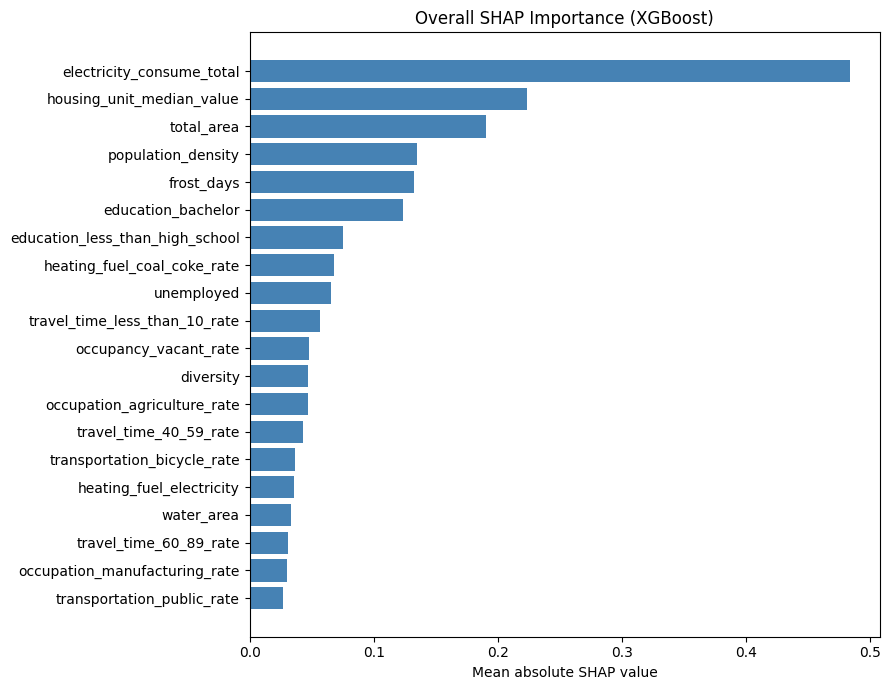

Saved to outputs/figures/03b_shap_overall_bar.png


In [6]:
top = shap_importance.head(20).sort_values('mean_abs_shap_overall')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top['feature'], top['mean_abs_shap_overall'], color='steelblue')
ax.set_xlabel('Mean absolute SHAP value')
ax.set_title(f'Overall SHAP Importance ({model_name})')
plt.tight_layout()
plt.savefig('../outputs/figures/03b_shap_overall_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved to outputs/figures/03b_shap_overall_bar.png')

## SHAP Summary Plots by Class

For multiclass models, each class has its own SHAP explanation. These plots show which features push predictions toward each class.

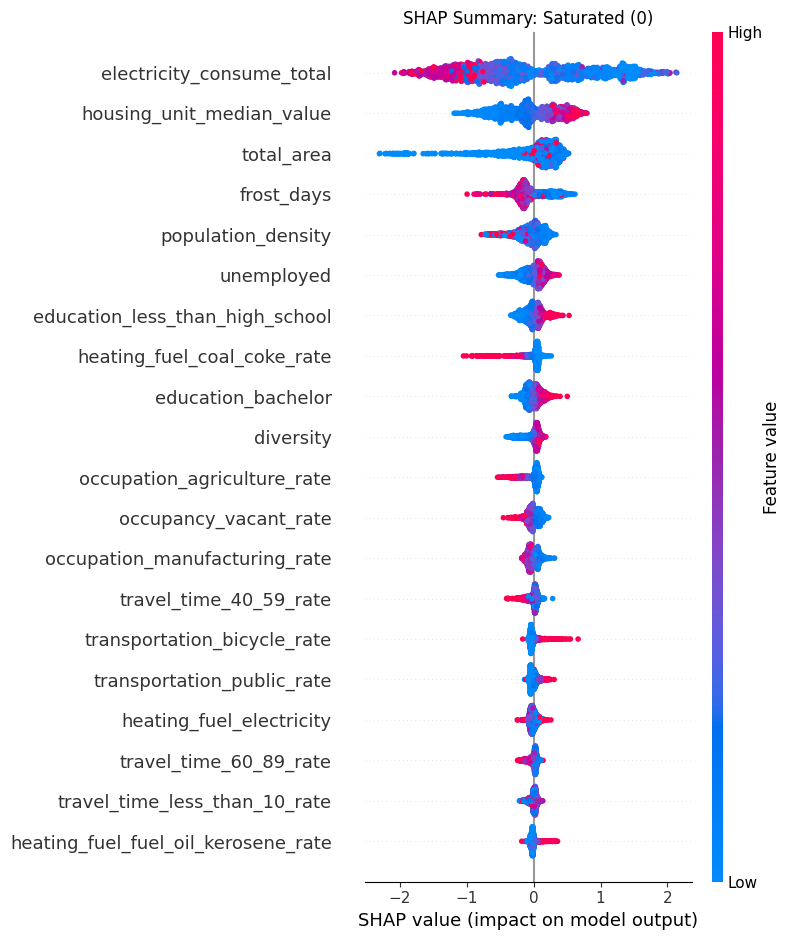

Saved to ../outputs/figures/03b_shap_summary_class_0.png


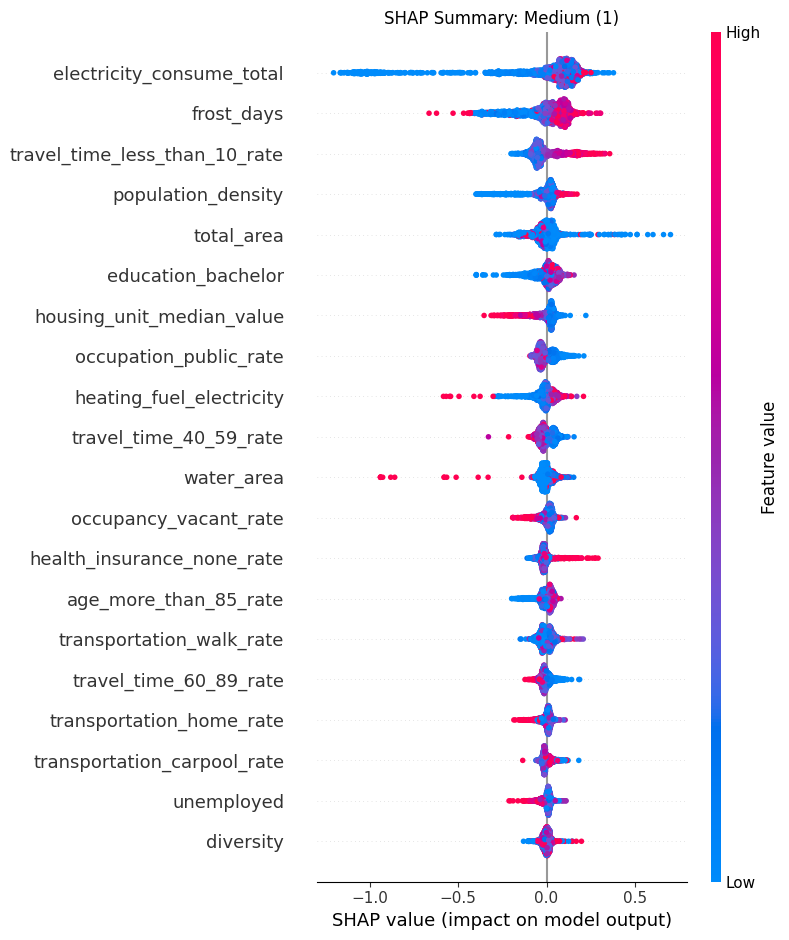

Saved to ../outputs/figures/03b_shap_summary_class_1.png


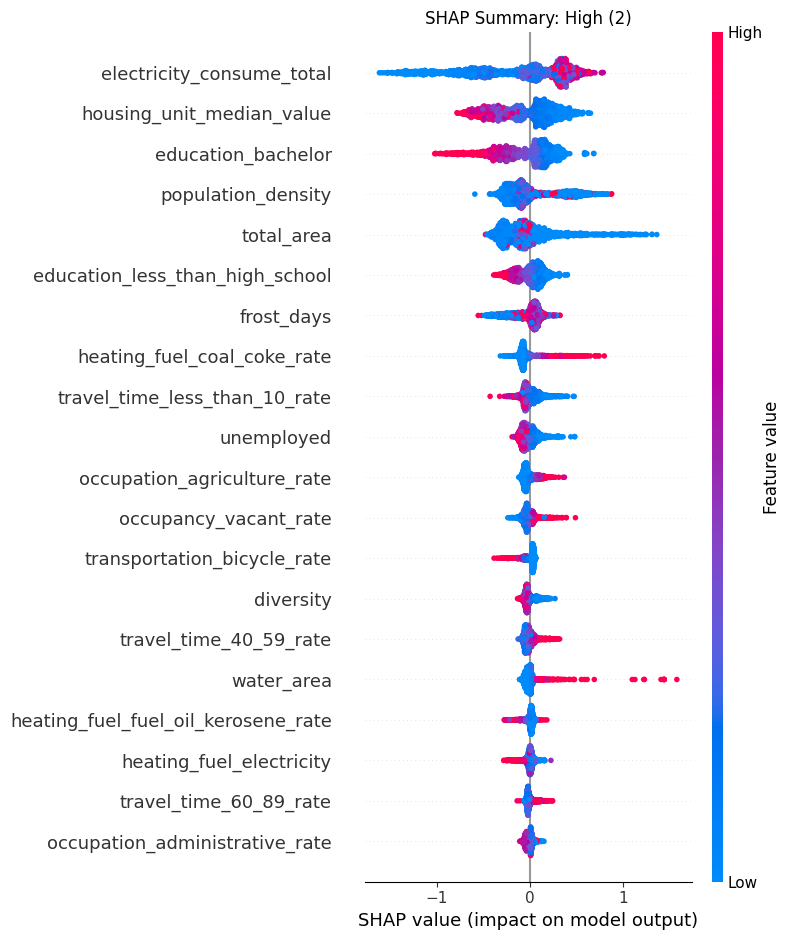

Saved to ../outputs/figures/03b_shap_summary_class_2.png


In [7]:
class_names = {
    0: 'Saturated',
    1: 'Medium',
    2: 'High',
}

for class_idx, values in enumerate(shap_values_by_class):
    plt.figure()
    shap.summary_plot(values, X_model_sample, max_display=20, show=False)
    class_label = class_names.get(class_idx, f'class_{class_idx}')
    plt.title(f'SHAP Summary: {class_label} ({class_idx})')
    plt.tight_layout()
    out_path = f'../outputs/figures/03b_shap_summary_class_{class_idx}.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved to {out_path}')

## Interpretation Notes

- SHAP explains how the trained model uses features for prediction.
- SHAP values are still model explanations, not causal effects.
- For multiclass classification, each class has a separate SHAP explanation.
- Positive SHAP values push a prediction toward the class being explained; negative values push it away from that class.